<a href="https://colab.research.google.com/github/LadyAlena/KAN/blob/main/KAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 5.1 MB/s eta 0:00:00


In [2]:
from kan import *

torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


Создаем модель KAN

In [3]:
model = KAN(width=[2, 5, 1], grid=5, k=3, seed=43, device=device)

checkpoint directory created: ./model
saving model version 0.0


Создаем датасет

In [4]:
from kan.utils import create_dataset
# f(x, y) = exp(sin(pi*x) + y^2)
f = lambda x: torch.exp(torch.sin(torch.pi * x[:, [0]]) + x[:, [1]]**2)
dataset = create_dataset(f, n_var=2, device=device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

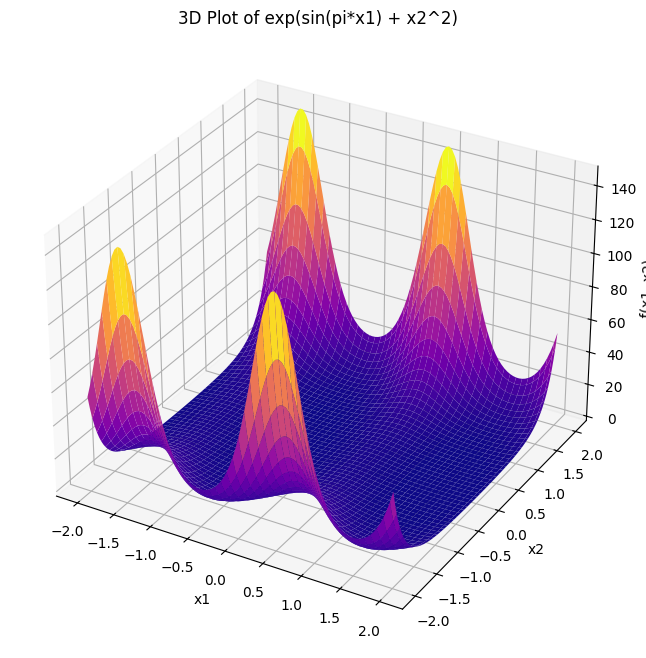

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the new function based on the provided lambda, adapted for numpy for plotting
def f_new(x1, x2):
    return np.exp(np.sin(np.pi * x1) + x2**2)

# Generate x and y values
x1_vals_new = np.linspace(-2, 2, 100)
x2_vals_new = np.linspace(-2, 2, 100)

X1_new, X2_new = np.meshgrid(x1_vals_new, x2_vals_new)

# Calculate Z values using the new function
Z_new = f_new(X1_new, X2_new)

# Create a 3D plot
fig_new = plt.figure(figsize=(10, 8))
ax_new = fig_new.add_subplot(111, projection='3d')

# Plot the surface
ax_new.plot_surface(X1_new, X2_new, Z_new, cmap='plasma')

# Set labels and title
ax_new.set_xlabel('x1')
ax_new.set_ylabel('x2')
ax_new.set_zlabel('f(x1, x2)')
ax_new.set_title('3D Plot of exp(sin(pi*x1) + x2^2)')

plt.show()

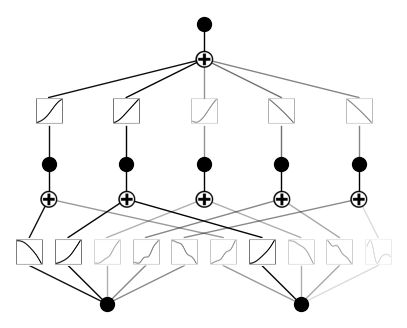

In [6]:
model(dataset['train_input']);
model.plot()

Обучение KAN с помощью регуляризации разреженности

In [7]:
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001);

| train_loss: 2.19e-02 | test_loss: 2.28e-02 | reg: 1.03e+01 | : 100%|█| 50/50 [00:20<00:00,  2.39it

saving model version 0.1


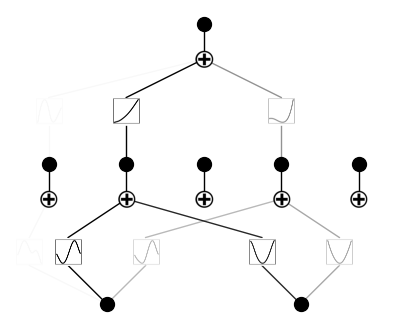

In [8]:
model.plot()

Обрезаем связи в KAN

saving model version 0.3


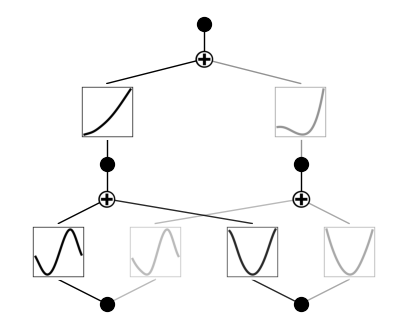

In [10]:
model = model.prune()
model.plot()

Дообучение

In [11]:
model.fit(dataset, opt="LBFGS", steps=50);

| train_loss: 4.22e-03 | test_loss: 4.58e-03 | reg: 1.22e+01 | : 100%|█| 50/50 [00:14<00:00,  3.50it

saving model version 0.4


In [12]:
model = model.refine(10);

saving model version 0.5


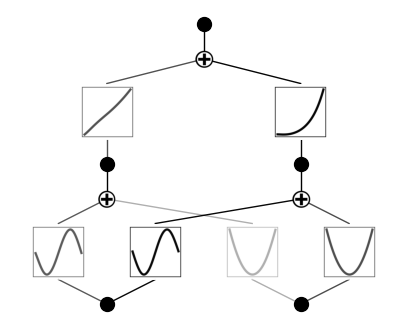

In [13]:
model.plot()

In [14]:
model.fit(dataset, opt="LBFGS", steps=50);

| train_loss: 3.85e-04 | test_loss: 4.32e-04 | reg: 1.22e+01 | : 100%|█| 50/50 [00:13<00:00,  3.61it

saving model version 0.6


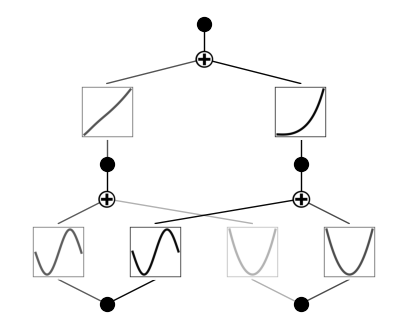

In [15]:
model.plot()

saving model version 0.10


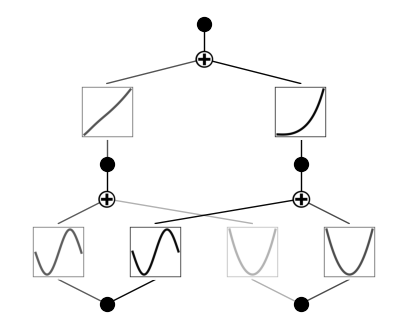

In [19]:
model = model.prune()
model.plot()

Аналитический вид функции

In [20]:
mode = "auto" # "manual"

if mode == "manual":
    # manual mode
    model.fix_symbolic(0,0,0,'sin');
    model.fix_symbolic(0,1,0,'x^2');
    model.fix_symbolic(1,0,0,'exp');
elif mode == "auto":
    # automatic mode
    lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
    model.auto_symbolic(lib=lib)

fixing (0,0,0) with sin, r2=0.9996463333736213, c=2
fixing (0,0,1) with sin, r2=0.9999547706612164, c=2
fixing (0,1,0) with x^2, r2=0.9999437306194637, c=2
fixing (0,1,1) with x^2, r2=0.9999875818485774, c=2
fixing (1,0,0) with x, r2=0.9984155630122892, c=1
fixing (1,1,0) with x^4, r2=0.999844856429275, c=3
saving model version 0.11


In [21]:
model.fit(dataset, opt="LBFGS", steps=50);

| train_loss: 1.00e-02 | test_loss: 9.36e-03 | reg: 0.00e+00 | : 100%|█| 50/50 [00:22<00:00,  2.27it

saving model version 0.12


In [22]:
from kan.utils import ex_round

ex_round(model.symbolic_formula()[0][0],4)

/usr/local/lib/python3.12/dist-packages/sympy/core/sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return sympify(float(a))


0.0047*(0.0022 - 10.0*x_2)**2 + 0.02*(-0.0119*(-10.0*x_2 - 0.0014)**2 - 1.1699*sin(3.1532*x_1 - 0.0043) - 1.7154)**4 + 0.4923*sin(3.1191*x_1 + 0.002) + 0.8364

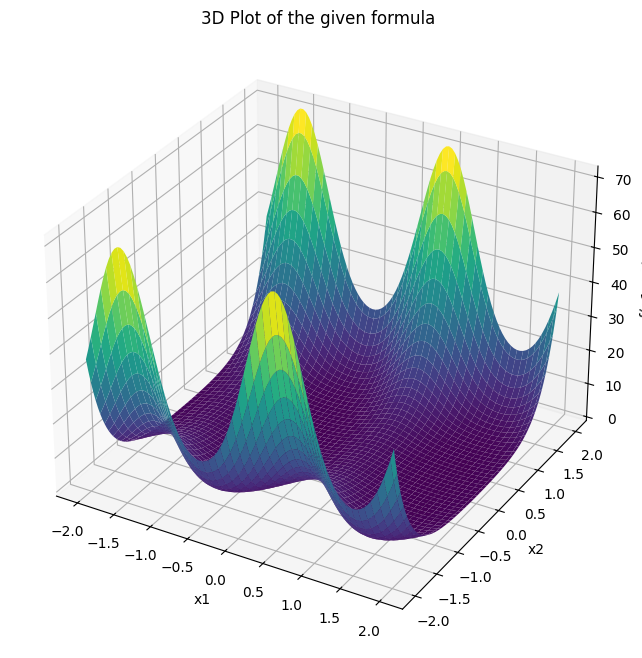

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the function based on the provided formula
def f(x1, x2):
    term1 = 0.0047 * (0.0022 - 10.0 * x2)**2
    term2 = 0.02 * (-0.0119 * (-10.0 * x2 - 0.0014)**2 - 1.1699 * np.sin(3.1532 * x1 - 0.0043) - 1.7154)**4
    term3 = 0.4923 * np.sin(3.1191 * x1 + 0.002)
    term4 = 0.8364
    return term1 + term2 + term3 + term4

# Generate x and y values
x1_vals = np.linspace(-2, 2, 100)
x2_vals = np.linspace(-2, 2, 100)

X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Calculate Z values using the function
Z = f(X1, X2)

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(X1, X2, Z, cmap='viridis')

# Set labels
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')
ax.set_title('3D Plot of the given formula')

plt.show()